# 02 · Categorical Verification — Precipitation

**Runnable companion to [`python-verification-guide.md`](../python-verification-guide.md).**

Precipitation should *never* be judged by RMSE alone — the score is dominated by
the many dry hours. Instead we verify **events** ("did it rain more than X mm?")
with a contingency table and categorical scores at several thresholds, then look
at spatial skill with the **Fractions Skill Score (FSS)**.

**Station:** Seattle–Tacoma (`KSEA`), 10–20 Jan 2024 — a wet maritime period
with plenty of rain events to score.

> Live data with committed cached fallback; see [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from meteo_examples import dataio, verif, sampledata

STATION, NETWORK = "KSEA", "WA_ASOS"
LAT, LON = 47.45, -122.31
START, END = "2024-01-10", "2024-01-20"
plt.rcParams["figure.dpi"] = 110

## 1 · Load and match hourly precipitation

In [2]:
fcst = dataio.open_meteo_forecast(LAT, LON, START, END,
                                  hourly="precipitation").rename(columns={"time": "valid"})

obs = dataio.iem_asos(STATION, START, END, network=NETWORK)
o = obs.dropna(subset=["p01m"]).copy()
o["valid"] = o["valid"].dt.floor("h")
o = o.groupby("valid", as_index=False)["p01m"].sum()        # mm per hour

m = pd.merge(fcst, o, on="valid", how="inner")
print(f"matched hours: {len(m)}   |   rainy hours (obs > 0.2 mm): {(m['p01m'] > 0.2).sum()}")
m.head()

matched hours: 240   |   rainy hours (obs > 0.2 mm): 29


,valid,precipitation,p01m
0,2024-01-10 00:00:00,0.0,0.0
1,2024-01-10 01:00:00,0.0,0.0
2,2024-01-10 02:00:00,0.4,0.0
3,2024-01-10 03:00:00,0.0,0.0
4,2024-01-10 04:00:00,0.0,0.0


## 2 · Contingency table for one threshold

A 2×2 table counts **hits** (forecast & observed), **false alarms** (forecast,
not observed), **misses** (observed, not forecast), and **correct negatives**.

In [3]:
thr = 0.5  # mm/hr
a, b, c, d = verif.contingency_table(m["precipitation"], m["p01m"], thr)
print(f"threshold = {thr} mm/hr")
print(pd.DataFrame([[a, b], [c, d]],
      index=["Fcst: yes", "Fcst: no"], columns=["Obs: yes", "Obs: no"]))
pd.DataFrame([verif.categorical_metrics(a, b, c, d)]).round(3)

threshold = 0.5 mm/hr
           Obs: yes  Obs: no
Fcst: yes        14       12
Fcst: no          9      205


,N,Hits,FA,Misses,CN,POD,FAR,POFD,SR,CSI,ETS,FBIAS,HK,HSS,ACC
0,240,14,12,9,205,0.609,0.462,0.055,0.538,0.4,0.354,1.13,0.553,0.523,0.912


## 3 · Scores across multiple thresholds

`POD` (hit rate) falls and `FAR` (false-alarm ratio) rises as the threshold
gets more demanding — a normal, expected pattern. `CSI` and `ETS` summarise
overall categorical skill (`ETS` is "equitable" — it removes hits expected by
chance).

In [4]:
table = verif.multi_threshold_table(m["precipitation"], m["p01m"], [0.1, 0.5, 1.0])
table[["threshold", "Hits", "FA", "Misses", "POD", "FAR", "CSI", "ETS", "FBIAS"]].round(3)

,threshold,Hits,FA,Misses,POD,FAR,CSI,ETS,FBIAS
0,0.1,21,16,8,0.724,0.432,0.467,0.408,1.276
1,0.5,14,12,9,0.609,0.462,0.400,0.354,1.130
2,1.0,6,13,5,0.545,0.684,0.250,0.222,1.727


## 4 · Performance diagram

One glance summarises POD, success ratio (1−FAR), bias, and CSI together. Points toward the top-right are better; the diagonal is unbiased.

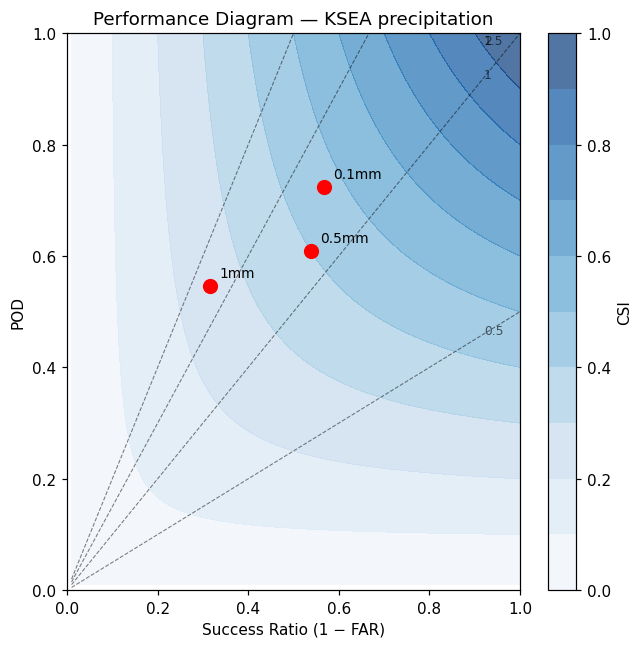

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
sr = np.linspace(0.01, 1, 100); pod = np.linspace(0.01, 1, 100)
SR, POD = np.meshgrid(sr, pod)
CSI = 1 / (1 / SR + 1 / POD - 1)
cs = ax.contourf(SR, POD, CSI, levels=np.arange(0, 1.1, 0.1), cmap="Blues", alpha=0.7)
for b_ in [0.5, 1, 1.5, 2]:                          # bias lines
    ax.plot(sr, b_ * sr, "k--", lw=0.7, alpha=0.5)
    ax.text(0.92, min(0.98, b_ * 0.92), f"{b_}", fontsize=8, alpha=0.6)
plt.colorbar(cs, label="CSI")
ax.scatter(1 - table["FAR"], table["POD"], c="red", s=80, zorder=5)
for _, r in table.iterrows():
    ax.annotate(f"{r['threshold']:g}mm", (1 - r["FAR"], r["POD"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Success Ratio (1 − FAR)",
       ylabel="POD", title=f"Performance Diagram — {STATION} precipitation")
plt.tight_layout()

## 5 · Spatial skill: the Fractions Skill Score (FSS)

Point scores can't see *spatial displacement* — a perfect rain band shifted by
one grid cell is doubly penalised (a miss **and** a false alarm). FSS compares
fractional coverage within growing neighbourhoods, so a near-miss scores well at
larger scales. Here we use a synthetic precip field and a copy shifted by a few
grid cells to show FSS rising with scale (the code is identical for real grids).

FSS by scale: {1: np.float64(0.73), 3: np.float64(0.77), 7: np.float64(0.81), 15: np.float64(0.87), 31: np.float64(0.92), 51: np.float64(0.95), 81: np.float64(0.98)}


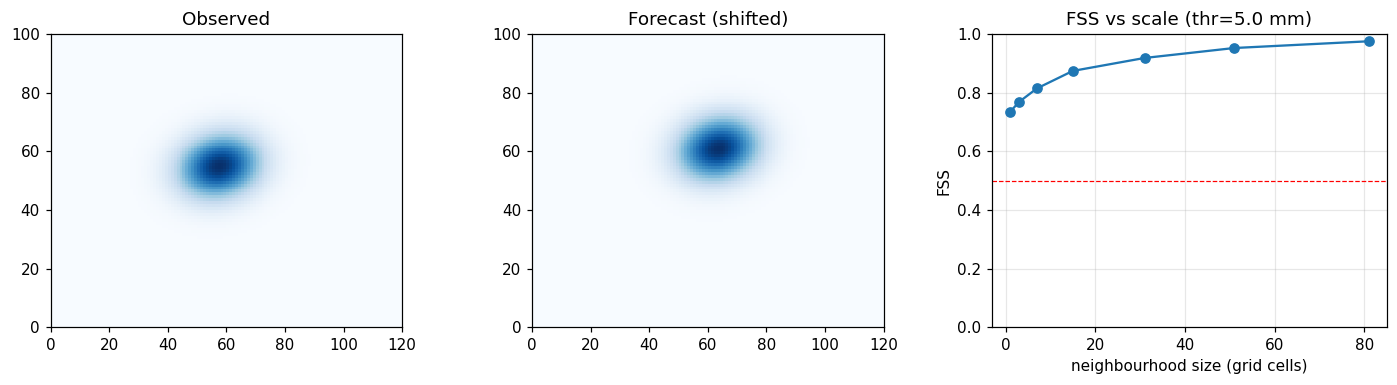

In [6]:
import xarray as xr, os
path = "/tmp/fss_demo_wrfout.nc"
if not os.path.exists(path):
    sampledata.make_wrfout(path)
ds = xr.open_dataset(path)
obs_field = (ds["RAINNC"] + ds["RAINC"]).isel(Time=-1).values    # "observed" precip
fcst_field = np.roll(np.roll(obs_field, 6, axis=0), 6, axis=1)    # forecast: shifted 6 cells

thr = 5.0  # mm
scales = [1, 3, 7, 15, 31, 51, 81]
fss = [verif.fractions_skill_score(fcst_field, obs_field, thr, w) for w in scales]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
vmax = float(obs_field.max())
axes[0].pcolormesh(obs_field, vmax=vmax, cmap="Blues"); axes[0].set_title("Observed")
axes[1].pcolormesh(fcst_field, vmax=vmax, cmap="Blues"); axes[1].set_title("Forecast (shifted)")
axes[2].plot(scales, fss, "o-"); axes[2].axhline(0.5, color="r", ls="--", lw=0.8)
axes[2].set(xlabel="neighbourhood size (grid cells)", ylabel="FSS",
            title=f"FSS vs scale (thr={thr} mm)", ylim=(0, 1))
axes[2].grid(alpha=0.3)
for a_ in axes[:2]:
    a_.set_aspect("equal")
plt.tight_layout()
print("FSS by scale:", {w: round(f, 2) for w, f in zip(scales, fss)})

FSS is near zero at the grid scale (the shifted field never overlaps
exactly) but climbs past the useful-skill line (≈0.5) once the neighbourhood is
large enough to contain the displacement — quantifying *at what scale* the
forecast becomes useful.

---
### What to try next
- Change `STATION`/dates to a convective regime and add higher thresholds.
- Use real gridded QPF and radar/gauge analysis for FSS instead of the synthetic
  fields, then find the minimum useful scale (see the guide).
- Continue to [`03_ensemble_crps.ipynb`](03_ensemble_crps.ipynb).